<a href="https://colab.research.google.com/github/Aayush-Rathod-11/Heart_Disease_Prediction_ML/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Connect Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Problem Statement

You are an ML Engineer at a tech company. Your task is to build, train, and evaluate a machine learning
model that predicts an outcome from real-world data. You must compare at least 3 different ML algorithms,
evaluate them using proper metrics, and clearly explain which model performed best and why.

# Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Load Dataset

In [13]:
# Load the Heart dataset directly from Google Drive using a public file ID.
# running the notebook to access the dataset through the internet.

df = pd.read_csv("https://drive.google.com/uc?id=15piaw2W2vC7s1mK4UojlNyP6Jc_ziHGf")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [12]:
"""
# This dataset is read from connected dive, it's other way to load the dataset

data = pd.read_csv("/content/drive/MyDrive/heart.csv")
data
"""

'\n# This dataset is read from connected dive, it\'s other way to load the dataset\n\ndata = pd.read_csv("/content/drive/MyDrive/heart.csv")\ndata\n'

# Data Inspection

In [15]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (1025, 14)


In [16]:
print("\n--- Data types & non-null counts ---")
df.info()


--- Data types & non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [17]:
print("\n--- Statistical summary ---")
display(df.describe())


--- Statistical summary ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [18]:
print("\n--- Missing values per column ---")
print(df.isnull().sum())


--- Missing values per column ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [19]:
print("\n--- Duplicate rows ---")
print("Number of duplicate rows:", df.duplicated().sum())


--- Duplicate rows ---
Number of duplicate rows: 723


# Data cleaning

In [20]:
# Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")

# Confirm target is binary
print("\nTarget value counts:")
print(df['target'].value_counts())

Removed 723 duplicate rows. New shape: (302, 14)

Target value counts:
target
1    164
0    138
Name: count, dtype: int64


# Train-Test-Split

In [28]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (241, 13) | Test shape: (61, 13)

Train target distribution:
 target
1    0.543568
0    0.456432
Name: proportion, dtype: float64

Test target distribution:
 target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


In [29]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Engineering

- Before training models, I want to understand which features actually relate to heart disease risk.
I'm using two approaches — correlation analysis and Random Forest feature importance — since they
catch different things: correlation shows linear relationships with the target, while feature
importance can pick up on non-linear patterns and interactions that correlation alone would miss.

### Correlation heatmap

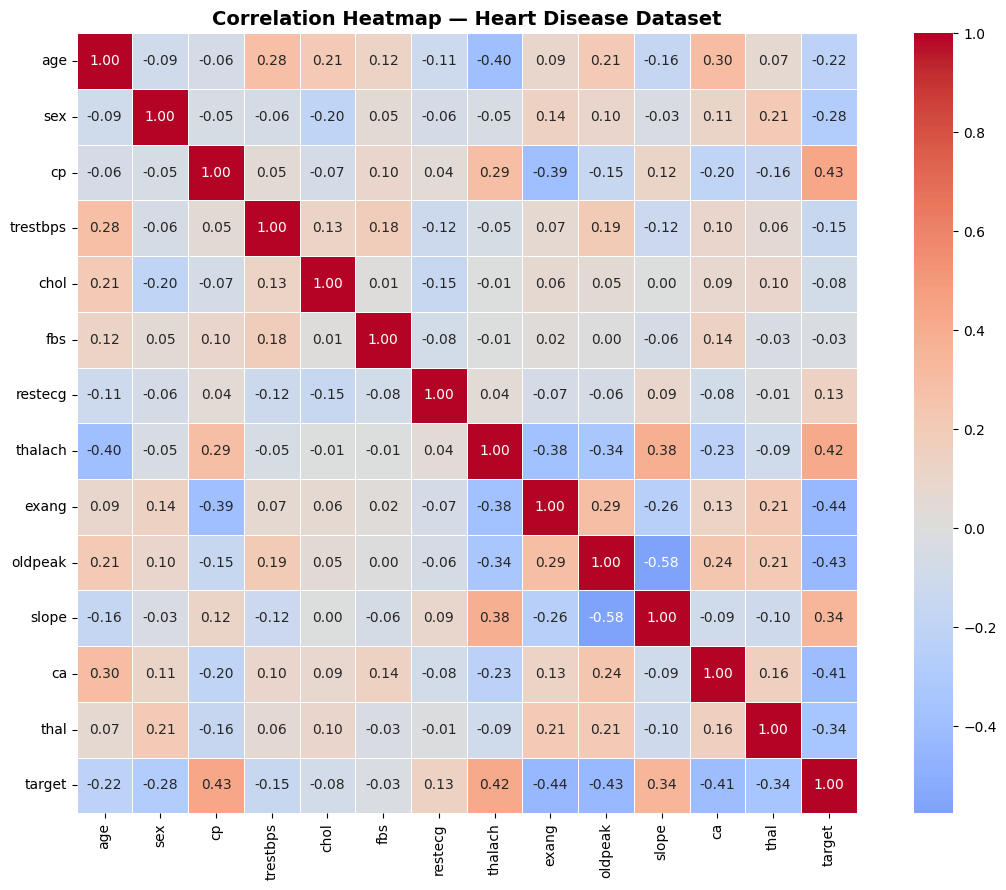

In [33]:
# import matplotlib.pyplot as plt
# import seaborn as sns

plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Isolate correlation with target specifically

Feature correlation with target (sorted by strength):

exang      -0.435601
cp          0.432080
oldpeak    -0.429146
thalach     0.419955
ca         -0.408992
slope       0.343940
thal       -0.343101
sex        -0.283609
age        -0.221476
trestbps   -0.146269
restecg     0.134874
chol       -0.081437
fbs        -0.026826
Name: target, dtype: float64


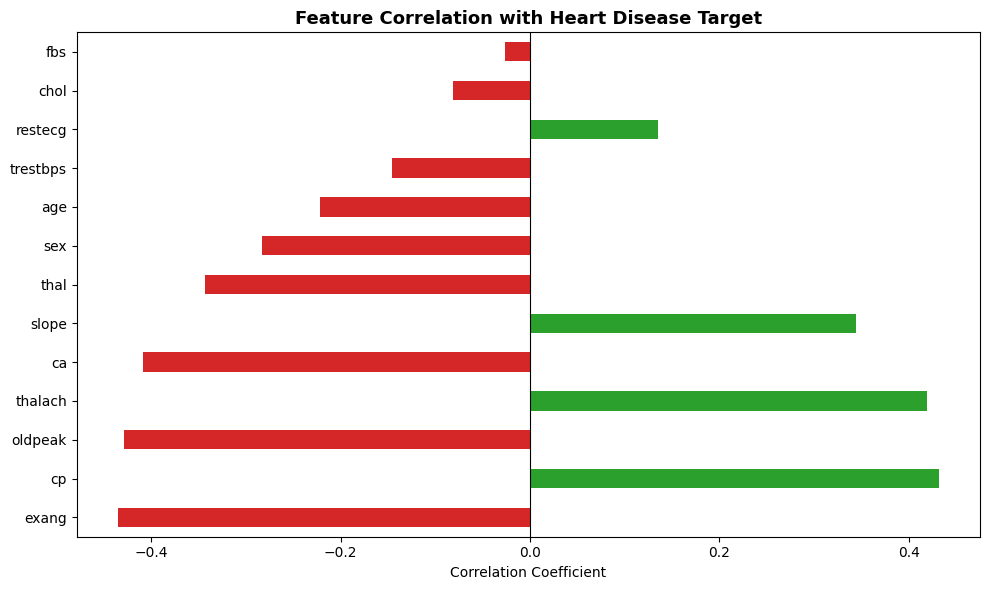

In [31]:
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print("Feature correlation with target (sorted by strength):\n")
print(target_corr)

plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh', color=['#d62728' if x < 0 else '#2ca02c' for x in target_corr])
plt.title('Feature Correlation with Heart Disease Target', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Interpret the correlation results

##### Correlation Findings

- The strongest correlations with **target** are [in this dataset it's **cp** (chest pain type), **thalach** (max heart rate), **exang** (exercise-induced
angina), and **oldpeak** (ST depression)].

- Positive correlation features (like cp, thalach) tend to *increase* with disease likelihood in how
they're encoded, while negative correlation features (like exang, oldpeak, ca) move in the opposite
direction. None of the correlations are extremely strong individually (mostly in the 0.2–0.45 range),
which suggests heart disease risk here isn't explained by any single variable — it's a combination of
factors, which is exactly why a multi-feature ML model is more useful than a simple rule-based check.

### Feature importance intro

##### Feature Importance (Random Forest)

- Correlation only captures linear relationships. To check for non-linear patterns, I'm fitting a quick
baseline Random Forest and looking at its built-in feature importance scores. This isn't the final
model — it's purely a diagnostic step to cross-check the correlation results.

### Quick baseline RF for feature importance

Feature importance (Random Forest):

thalach     0.130246
cp          0.126030
oldpeak     0.118301
thal        0.113892
ca          0.096178
age         0.090891
trestbps    0.074502
chol        0.072694
slope       0.052614
exang       0.047001
sex         0.038327
restecg     0.027020
fbs         0.012303
dtype: float64


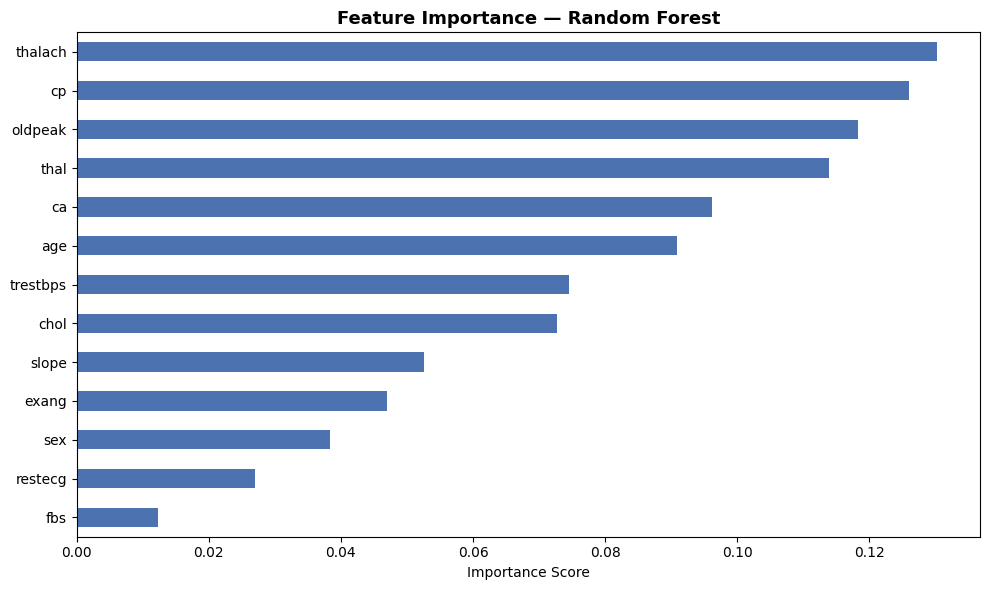

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Quick diagnostic model — not the final tuned model used later
rf_diagnostic = RandomForestClassifier(n_estimators=200, random_state=42)
rf_diagnostic.fit(X_train, y_train)

importances = pd.Series(rf_diagnostic.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("Feature importance (Random Forest):\n")
print(importances)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#4c72b0')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Compare both methods and make the final call

##### Feature Engineering Conclusion

- Comparing both methods: [fill in — e.g., "**cp**, **thalach**, **ca**, and **oldpeak** rank highly in
both correlation and feature importance, confirming they're strong predictors. **thal** and **exang**
also rank highly in feature importance despite moderate correlation scores, suggesting they contribute
through non-linear interactions that correlation alone doesn't capture."]

- **Decision: No features are being dropped.** All 13 features show at least some predictive signal in
one or both methods, and tree-based models like Random Forest naturally down-weight irrelevant features
during training rather than being harmed by their inclusion. Removing features here would risk losing
information without a clear benefit, especially with a feature set this small (13 columns).

# Train 3 Models